In [23]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
from scipy.stats import multivariate_normal

import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import jax.random as jr
import blackjax
import arviz as az

In [24]:
rng_key = jr.key(5);
prior_cov_matrix = jnp.array([[1.0, 0],
                       [0, 1.0]])
measurement_error_bar = 0.1;
# Measurement: e^x + e^y = 1 +\- 0.1
def log_density_fcn(x, y):
    log_P_data_given_signal = -0.5*((jnp.exp(x) + jnp.exp(y) - 1)/measurement_error_bar)**2;
    v = jnp.array([x, y]);
    log_P_signal =  -0.5*v.T @ jnp.linalg.inv(prior_cov_matrix) @ v; 
    return log_P_data_given_signal + log_P_signal;

logdensity = lambda x: log_density_fcn(**x)

inv_mass_matrix = prior_cov_matrix;
num_integration_steps = 2000
step_size = 5e-4
num_chains = 4
keys = jax.random.split(rng_key, 2)

hmc = blackjax.hmc(logdensity, step_size, inv_mass_matrix, num_integration_steps)

initial_positions = {
    "x": jax.random.normal(keys[0], (num_chains,))*1.5,
    "y": jax.random.normal(keys[1], (num_chains,))*1.5
}
initial_states = jax.vmap(hmc.init)(initial_positions)
initial_states

HMCState(position={'x': Array([ 0.622924  ,  1.72558   , -0.99751425,  1.8623106 ], dtype=float32), 'y': Array([-2.0698051, -1.1121603, -1.8212099, -0.9258809], dtype=float32)}, logdensity=Array([  -51.39867 , -1224.573   ,   -13.171571, -1704.3948  ], dtype=float32), logdensity_grad={'x': Array([ -185.30414 , -2778.5166  ,    18.307837, -3758.6409  ], dtype=float32), 'y': Array([ -10.4323635, -161.4907   ,    9.4171   , -230.23769  ], dtype=float32)})

In [ ]:
num_HMC_data = 10000
num_warmup_data = 100
hmc_kernel = jax.jit(hmc.step)

def inference_loop(rng_key, kernel, initial_state, num_samples):
    @jax.jit
    def one_step(state, rng_key):
        state, info = kernel(rng_key, state)
        return state, (state, info)

    keys = jax.random.split(rng_key, num_samples)
    _, (states, infos) = jax.lax.scan(one_step, initial_state, keys)
    return states, infos


rng_key, sample_key = jax.random.split(rng_key)
sample_keys = jax.random.split(sample_key, num_chains)
states, infos = jax.vmap(inference_loop, in_axes=(0, None, 0, None))(sample_keys, hmc_kernel, initial_states, num_HMC_data)

mcmc_samples = states.position

# This tells JAX: "Run blackjax.rhat on every array inside states.position"
rhat_dict = jax.tree_util.tree_map(blackjax.rhat, states.position)

print(f"R-hat for x: {rhat_dict['x']}")
print(f"R-hat for y: {rhat_dict['y']}")

ess_dict = jax.tree_util.tree_map(blackjax.ess, states.position)

print(f"Effective Sample Size for x: {ess_dict['x']}")
print(f"Effective Sample Size for y: {ess_dict['y']}")

dataset_x = az.from_dict(
    {  
        "posterior": {"x": states.position["x"][:, num_warmup_data:]},
        "sample_stats": {
            "diverging": infos.is_divergent,
            "acceptance_rate": infos.acceptance_rate,
        }
    }  
)

dataset_y = az.from_dict(
    {  
        "posterior": {"y": states.position["y"][:, num_warmup_data:]},
        "sample_stats": {
            "diverging": infos.is_divergent,
            "acceptance_rate": infos.acceptance_rate,
        }
    }  
)


az.summary(dataset_x)
az.plot_trace(dataset_x)
az.plot_autocorr(dataset_x)
plt.show()


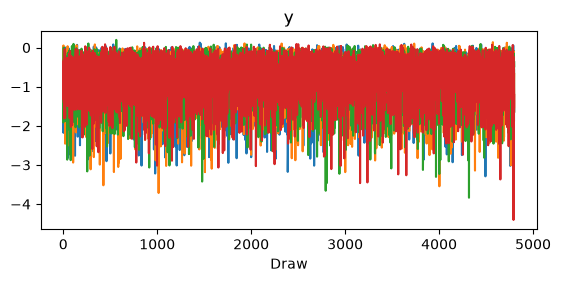

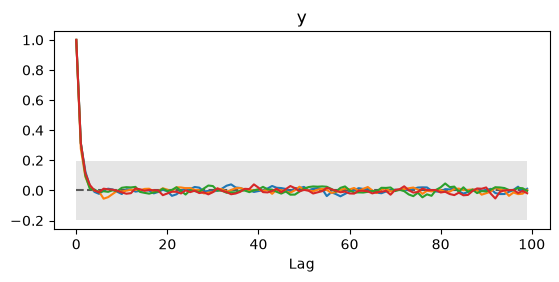

In [ ]:
az.summary(dataset_y)
az.plot_trace(dataset_y)
az.plot_autocorr(dataset_y)
plt.show()

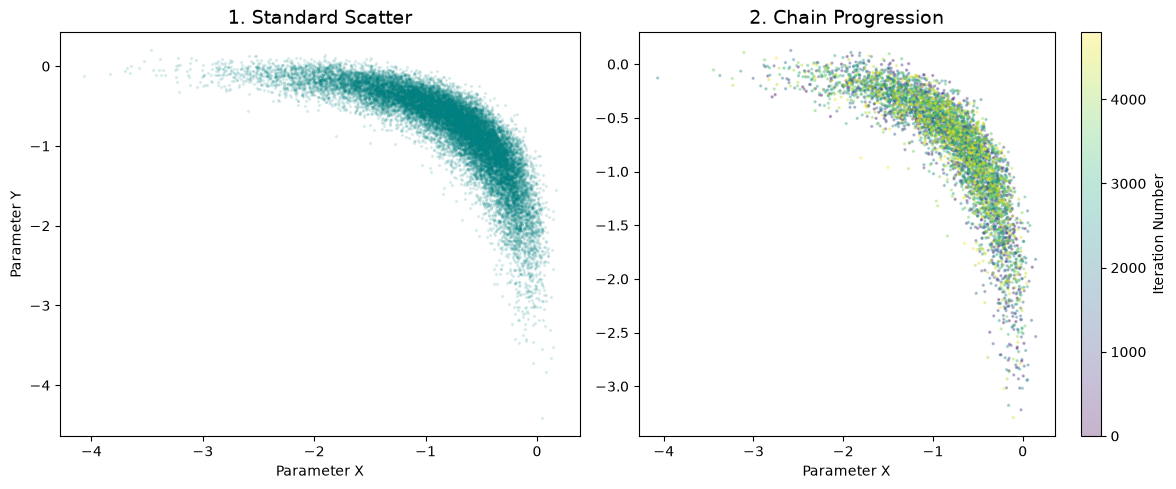

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
mcmc_samples["x"] = mcmc_samples["x"][:, num_warmup_data:]
mcmc_samples["y"] = mcmc_samples["y"][:, num_warmup_data:]
axes[0].scatter(mcmc_samples["x"], mcmc_samples["y"], alpha=0.1, s=2, color='teal')
axes[0].set_title("1. Standard Scatter", fontsize=14)
axes[0].set_xlabel("Parameter X")
axes[0].set_ylabel("Parameter Y")

# ---------------------------------------------------------
# SUBPLOT 2: Plots the progression for ONLY the first chain
# ---------------------------------------------------------
iterations = np.arange(len(mcmc_samples["x"][0]))
scatter2 = axes[1].scatter(mcmc_samples["x"][0], mcmc_samples["y"][0], 
                           c=iterations, cmap='viridis', alpha=0.3, s=2)
axes[1].set_title("2. Chain Progression", fontsize=14)
axes[1].set_xlabel("Parameter X")
# For colorbars in subplots, you must tell it which axis to attach to
fig.colorbar(scatter2, ax=axes[1], label="Iteration Number") 

# 3. Final Polish and Display
plt.tight_layout() # Prevents overlapping text/labels between the plots
plt.show()

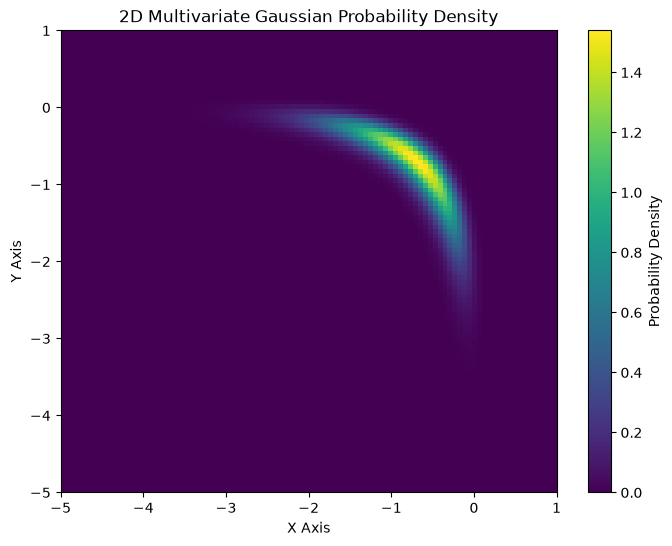

In [ ]:
# Testing whether these samples are accurate

#Method: Grid the posterior, compute the expected number of samples in each square with the actual number of samples in each square

#Plot the posterior in a grid

x = jnp.linspace(-5, 1, 100)
y = jnp.linspace(-5, 1, 100)


X, Y = np.meshgrid(x, y)


pos = np.dstack((X, Y))

# 3. Compute the multivariate Gaussian PDF on the grid
rv = multivariate_normal([0.0, 0.0], prior_cov_matrix) 
Z = rv.pdf(pos) * jnp.exp(-0.5*((jnp.exp(X) + jnp.exp(Y) - 1)/measurement_error_bar)**2)

total_prob_density = jnp.sum(Z)*0.06**2;
normalized_density = Z/total_prob_density

# 4. Plot the heatmap
plt.figure(figsize=(8, 6))
# 'origin=lower' ensures the y-axis increases upwards
# 'cmap' sets the color palette (viridis, plasma, and inferno work great)
heatmap = plt.imshow(normalized_density, extent=[-5, 1, -5, 1], origin='lower', cmap='viridis', aspect='auto')

# Add a colorbar, labels, and title
plt.colorbar(heatmap, label='Probability Density')
plt.title('2D Multivariate Gaussian Probability Density')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')

# Display the plot
plt.show()

Actual chi_2 value 997.7269287109375
Degrees of freedom 551
Chi 2 statistic 3.1801542650355077e-28


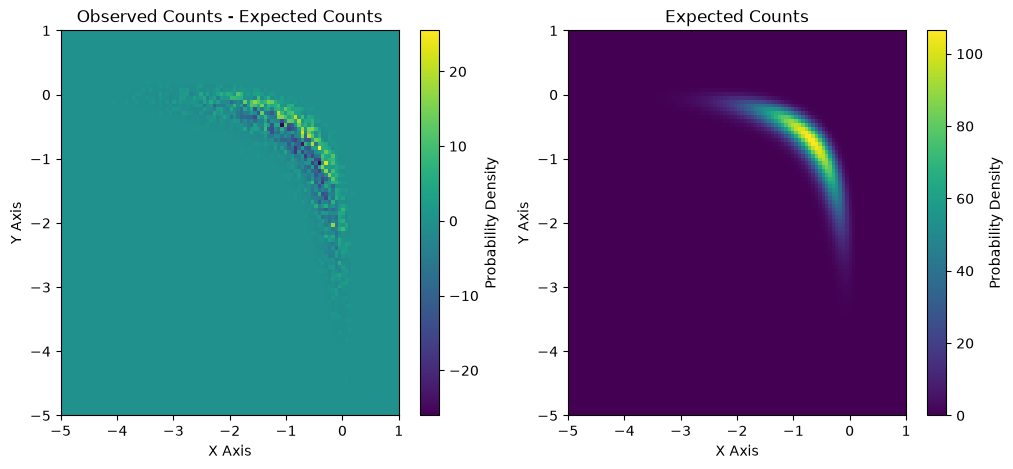

In [ ]:
expected_counts = num_chains*normalized_density*(num_HMC_data - num_warmup_data)*0.06**2

observed_counts = jnp.zeros(Z.shape)
x_values = jnp.floor((mcmc_samples["x"] + 5) * 100 / 6.0).astype(int)
y_values = jnp.floor((mcmc_samples["y"] + 5) * 100 / 6.0).astype(int)
observed_counts = observed_counts.at[y_values, x_values].add(1)

chi_2_significance_mask = expected_counts >= 5

important_expected_counts = expected_counts[chi_2_significance_mask]
important_observed_counts = observed_counts[chi_2_significance_mask]
chi_2 = jnp.sum((important_observed_counts - important_expected_counts)**2/important_expected_counts)


print(f"Actual chi_2 value {chi_2}")
print(f"Degrees of freedom {important_expected_counts.size - 1}")
sf = stats.chi2.sf(chi_2, important_expected_counts.size - 1)
print(f"Chi 2 statistic {sf}")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

heatmap1 = axes[0].imshow(observed_counts - expected_counts, extent=[-5, 1, -5, 1], origin='lower', cmap='viridis', aspect='auto')

# 2. Call colorbar from the figure object, and tell it which axes to attach to
fig.colorbar(heatmap1, ax=axes[0], label='Probability Density')
axes[0].set_title('Observed Counts - Expected Counts')
axes[0].set_xlabel('X Axis')
axes[0].set_ylabel('Y Axis')

heatmap2 = axes[1].imshow(expected_counts, extent=[-5, 1, -5, 1], origin='lower', cmap='viridis', aspect='auto')

# 2. Call colorbar from the figure object, and tell it which axes to attach to
fig.colorbar(heatmap2, ax=axes[1], label='Probability Density')
axes[1].set_title('Expected Counts')
axes[1].set_xlabel('X Axis')
axes[1].set_ylabel('Y Axis')

# Display the plot
plt.show()


In [ ]:
# Calculate KL Divergence
# adding some "jitter" to the HMC density for squares where there are no observed counts so that the KL divergence does not diverge to infinity

def KL_divergence(expected_probs, observed_probs, jitter):
    usable_expected_probs = jnp.where(expected_probs == 0, jitter, expected_probs)
    usable_observed_probs = jnp.where(observed_probs == 0, jitter, observed_probs)
    KL_array = usable_expected_probs*(jnp.log(usable_expected_probs) - jnp.log(usable_observed_probs))
    return jnp.sum(KL_array)



expected_bin_prob = expected_counts/(num_HMC_data - num_warmup_data)
observed_bin_prob = observed_counts/(num_HMC_data - num_warmup_data)
KL_div = KL_divergence(expected_bin_prob, observed_bin_prob, jitter = 1e-5)
print(f": KL Divergence of HMC samples of banana distribution {KL_div}")

: KL Divergence of HMC samples of banana distribution 0.1950855851173401
